In [7]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from rlxutils import subplots

# Exploratory Data Analysis

El primer paso en el análissi de datos y en los flujos de Machine Learning, es la exploración y el análisis del dataset para entender su estructura y principales patrones antes de aplicar cualquier modelo.

Dataset: https://www.kaggle.com/datasets/nabihazahid/spotify-dataset-for-churn-analysis/data

In [9]:
df = pd.read_csv("spotify_churn_dataset.csv")

Columns (Features):

`user_id` → Unique identifier for each user

`gender` → User gender (Male/Female/Other)

`age` → User age

`country` → User location

`subscription_type` → Type of Spotify subscription (Free, Premium, Family, Student)

`listening_time` → Minutes spent listening per day

`songs_played_per_day` → Number of songs played daily

`skip_rate` → Percentage of songs skipped

`device_type` → Device used (Mobile, Desktop, Web)

`ads_listened_per_week` → Number of ads heard per week

`offline_listening` → Offline mode usage

`is_churned` → **Target variable** (0 = Active, 1 = Churned)

Dataset Type: Mixed (numeric + categorical)

In [ ]:
print("shape:", df.shape)
print("\nis_churned_count:", df['is_churned'].value_counts())

shape: (8000, 12)

is_churned_count: is_churned
0    5929
1    2071
Name: count, dtype: int64


In [ ]:
df.dtypes

,0
user_id,int64
gender,object
age,int64
country,object
subscription_type,object
listening_time,int64
songs_played_per_day,int64
skip_rate,float64
device_type,object
ads_listened_per_week,int64


In [ ]:
df.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


No se encontraron valores nulos en ninguna de las columnas del dataset, lo que simplifica la fase de preprocesamiento.

In [ ]:
df.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


In [ ]:
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


Analizando las variables categóricas y sus clases:

In [ ]:
print("gender: ", df['gender'].unique())
print("countries: ", df['country'].unique())
print("subscription_types: ", df['subscription_type'].unique())
print("device_types: ", df['device_type'].unique())

gender:  ['Female' 'Other' 'Male']
countries:  ['CA' 'DE' 'AU' 'US' 'UK' 'IN' 'FR' 'PK']
subscription_types:  ['Free' 'Family' 'Premium' 'Student']
device_types:  ['Desktop' 'Web' 'Mobile']


/tmp/ipykernel_30289/1681139947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='is_churned', palette='viridis')


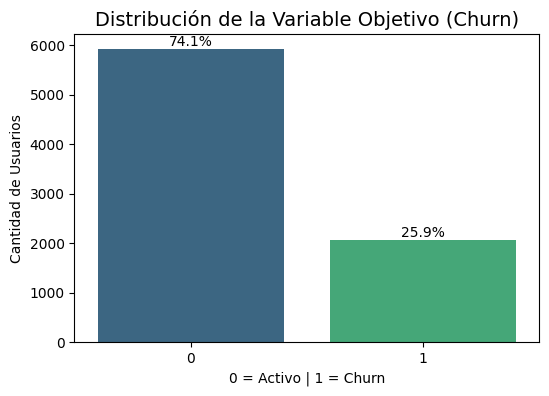

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='is_churned', palette='viridis')
plt.title('Distribución de la Variable Objetivo (Churn)', fontsize=14)
plt.xlabel('0 = Activo | 1 = Churn')
plt.ylabel('Cantidad de Usuarios')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

El dataset presenta un desbalance en la variable objetivo, con aproximadamente el 74.1% de usuarios activos (0) y el 25.9% de usuarios con 'churn' (1). Esto es un factor importante a considerar en el modelado.

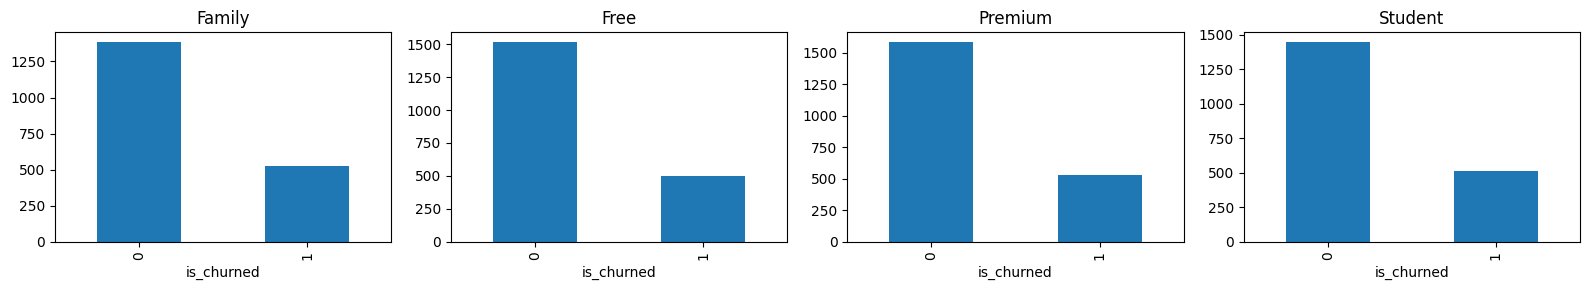

In [ ]:
c = sorted(df.subscription_type.value_counts().index)
for ax,ci in subplots(c, n_cols=4, usizex=4):
    dc = df[df.subscription_type==ci]
    dc.is_churned.value_counts().plot(kind='bar')
    plt.title(ci)

Analizando la distribución de la variable de respuesta `is_churned` para cada plan de subscripción, obsevamos que aunque hayan 4 tipos diferentes de suscripción, la proporción de los usuarios que han abandonado la plataforma (0) vs los usuarios que aún siguen activos (1), es consistente a lo largo de las categorías. Esto sugiere que, individualmente, `subscription_type` no altera significativamente la probabilidad de un usuario de hacer *churn*

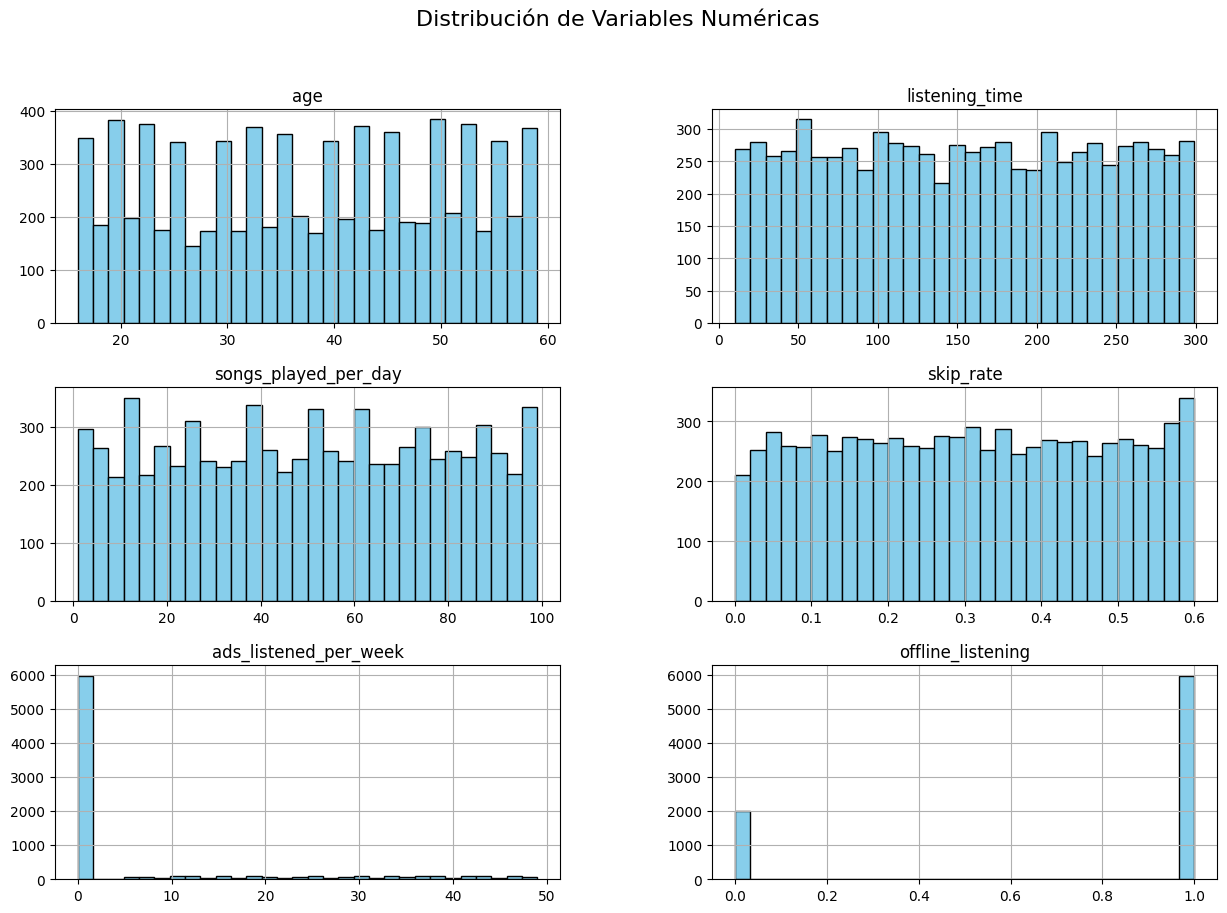

In [ ]:
num_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week', 'offline_listening']

df[num_cols].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribución de Variables Numéricas', fontsize=16)
plt.show()

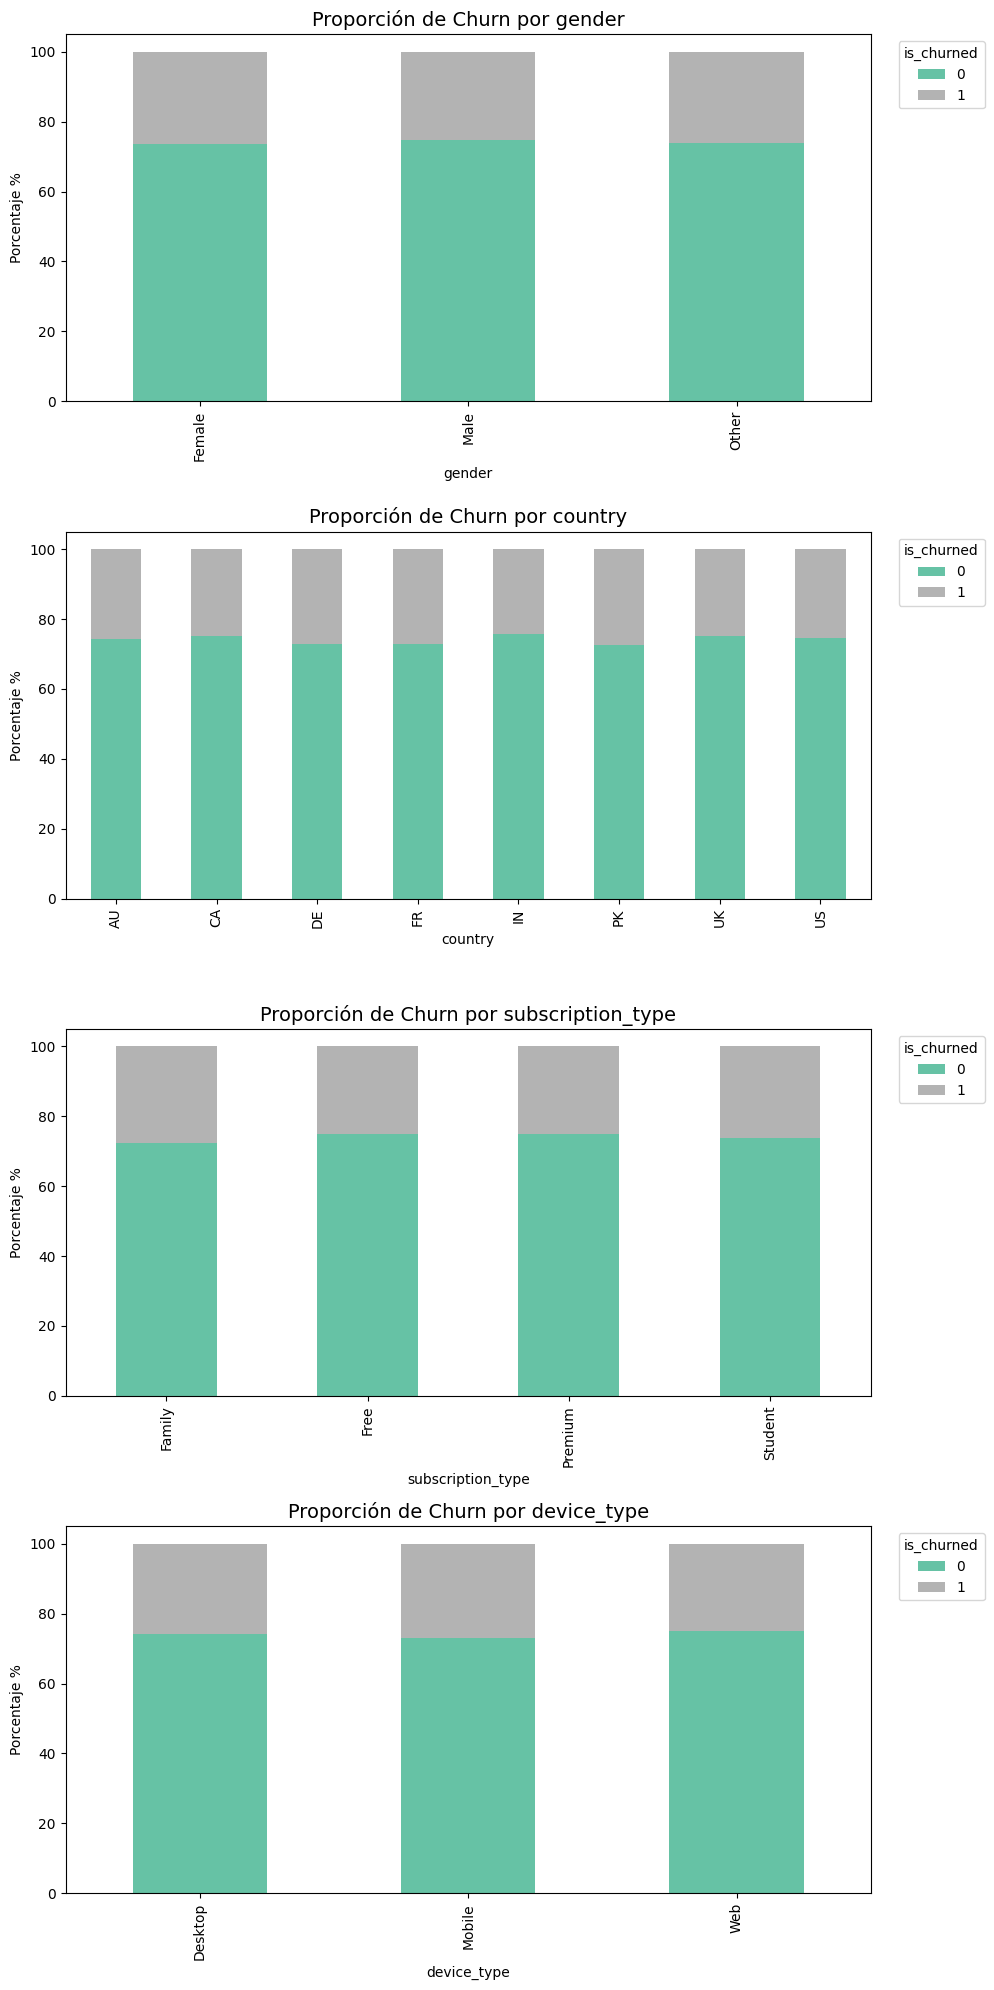

In [ ]:
cat_cols = ['gender', 'country', 'subscription_type', 'device_type']

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 5 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    # Calcular la proporción de churn dentro de cada categoría
    ct = pd.crosstab(df[col], df['is_churned'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2')

    axes[i].set_title(f'Proporción de Churn por {col}', fontsize=14)
    axes[i].set_ylabel('Porcentaje %')
    axes[i].legend(title='is_churned', loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

A partir del análisis bivariado con nuestra variable objetivo, se observa un fenómeno estadístico relevante: de forma aislada, ninguna de las variables categóricas (`gender`, `country`, `subscription_type`, `device_type`) altera significativamente la probabilidad base de la variable objetivo. En todas las categorías, la proporción se mantiene en el margen del balance global del dataset (aproximadamente 74.1% activos y 25.9% churned).


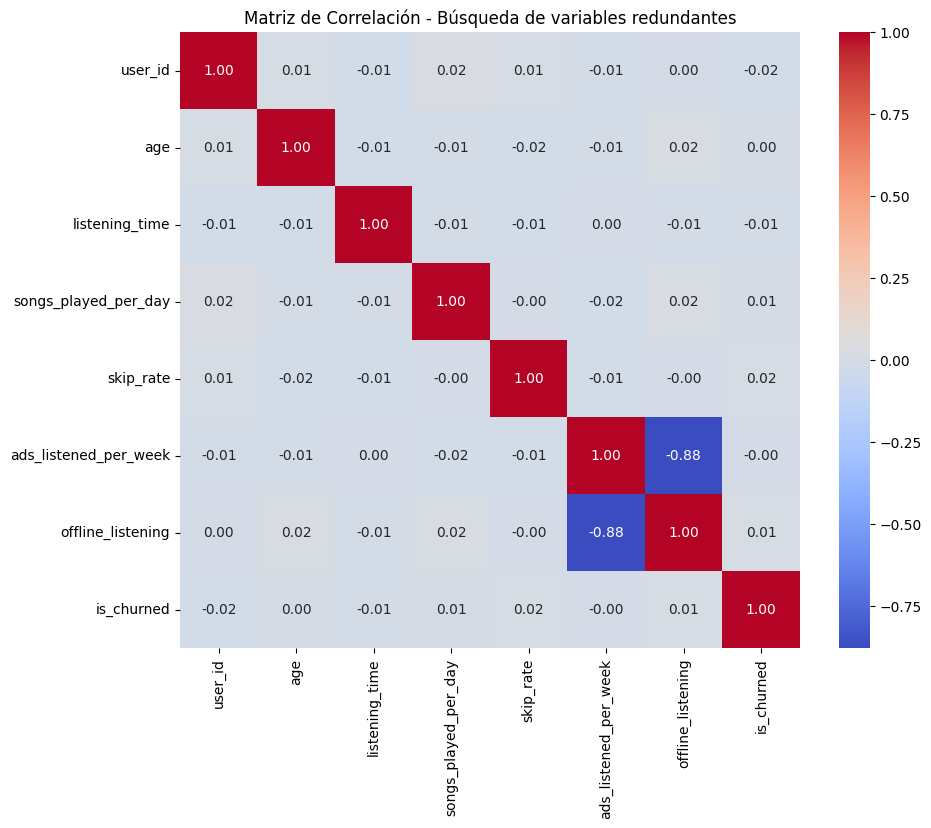

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación - Búsqueda de variables redundantes')
plt.show()

Durante la evaluación de la matriz de correlación de Pearson, se detectó una fuerte correlación negativa de -0.88 entre las variables `ads_listened_per_week` y `offline_listening`.

Analizando este fenómeno desde el dominio del negocio, se evidencia que ambas variables son lógicamente excluyentes debido a la estructura del servicio de Spotify: la escucha en modo *offline* es una funcionalidad reservada para usuarios con planes de pago, mientras que la exposición a anuncios es exclusiva de los planes gratuitos.

**Comprobación de la dependencia entre el tipo de suscripción y los anuncios**

In [ ]:
ads_by_plan = df.groupby('subscription_type')['ads_listened_per_week'].agg(['mean', 'min', 'max', 'count'])
print("Análisis de Anuncios por Tipo de Suscripción:")
display(ads_by_plan)

Análisis de Anuncios por Tipo de Suscripción:


,mean,min,max,count
subscription_type,,,,
Family,0.00000,0,0,1908
Free,27.52775,5,49,2018
Premium,0.00000,0,0,2115
Student,0.00000,0,0,1959


Se verificó que los tipos de suscripción de pago (Family, Premium, Student) tienen un promedio de 0 anuncios escuchados por semana, mientras que la suscripción *'Free'* presenta un promedio significativo de anuncios (aproximadamente 27.27 ads/semana), confirmando la lógica de negocio.

**Manejo de Multicolinealidad:** Aunque `ads_listened_per_week` y `offline_listening` son altamente correlacionadas y `subscription_type` también tiene una fuerte relación con ambas, se decidió conservar `subscription_type` y `ads_listened_per_week`.
*   `subscription_type` ofrece un control categórico sobre el comportamiento general de usuarios de pago versus gratuitos.
*   `ads_listened_per_week` aporta información valiosa sobre la *intensidad* de la exposición a anuncios dentro del segmento 'Free', lo cual podría ser un predictor más fino de la presión de abandono.
*   Eliminar el tipo de suscripción podría hacer perder matices en la retención entre diferentes planes de pago (ej. Familiar vs. Estudiante).

## Analisis UniVariable

Siguiendo los lineamientos metodológicos del proyecto, el objetivo de esta sección es evaluar matemáticamente si existe alguna característica candidata a ser eliminada por falta de poder predictivo, o si, por el contrario, hay variables que por sí solas logren separar las clases (Activo vs. Churn).

Para evitar sesgos de interpretación visual, aplicaremos dos pruebas estadísticas rigurosas:
1. **Prueba de Kolmogorov-Smirnov (KS):** Para variables continuas/discretas. Mide la distancia máxima entre las funciones de distribución acumulada de ambas clases. Un valor cercano a 0 indica que las distribuciones están perfectamente superpuestas.
2. **V de Cramér:** Para variables categóricas. Mide la fuerza de asociación respecto a la variable objetivo, donde 0 indica ausencia total de relación lineal.

In [12]:
from scipy.stats import ks_2samp, chi2_contingency

print("Calculando Índices de Discriminación y Distancias Probabilísticas...\n")

resultados = []

# Distancia Probabilística para Variables Numéricas (Kolmogorov-Smirnov)
num_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week', 'offline_listening']

for col in num_cols:
    clase_0 = df[df['is_churned'] == 0][col]
    clase_1 = df[df['is_churned'] == 1][col]

    stat, p_value = ks_2samp(clase_0, clase_1)

    resultados.append({
        'Variable': col,
        'Tipo': 'Numérica',
        'Métrica': 'Distancia KS',
        'Valor_Discriminación': round(stat, 4),
        'Significancia (p-value)': round(p_value, 4)
    })

# Índice de Discriminación para Categóricas (V de Cramér)
cat_cols = ['gender', 'country', 'subscription_type', 'device_type']

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

for col in cat_cols:
    v_stat = cramers_v(df[col], df['is_churned'])
    resultados.append({
        'Variable': col,
        'Tipo': 'Categórica',
        'Métrica': 'V de Cramér',
        'Valor_Discriminación': round(v_stat, 4),
        'Significancia (p-value)': '-'
    })

tabla_discriminacion = pd.DataFrame(resultados).sort_values(by='Valor_Discriminación', ascending=False)
display(tabla_discriminacion)

Calculando Índices de Discriminación y Distancias Probabilísticas...



,Variable,Tipo,Métrica,Valor_Discriminación,Significancia (p-value)
2,songs_played_per_day,Numérica,Distancia KS,0.0261,0.2433
3,skip_rate,Numérica,Distancia KS,0.0251,0.2821
1,listening_time,Numérica,Distancia KS,0.0192,0.6122
0,age,Numérica,Distancia KS,0.0137,0.9306
8,subscription_type,Categórica,V de Cramér,0.0135,-
4,ads_listened_per_week,Numérica,Distancia KS,0.0126,0.9636
5,offline_listening,Numérica,Distancia KS,0.0126,0.9636
9,device_type,Categórica,V de Cramér,0.0068,-
7,country,Categórica,V de Cramér,0.0000,-
6,gender,Categórica,V de Cramér,0.0000,-


**Interpretación de Resultados:**
Los resultados obtenidos revelan una ausencia casi total de poder discriminativo a nivel univariado. Los valores de la distancia KS (para variables numéricas) y la V de Cramér (para categóricas) son cercanos a 0. Esto demuestra empíricamente que las distribuciones de los usuarios que abandonan el servicio y los que permanecen activos están superpuestas de manera casi simétrica en cada una de las dimensiones.

No es posible establecer reglas simples del tipo *"si la edad es mayor a X, el usuario hará churn"*.

## Conclusiones

El análisis exploratorio de datos (EDA) ha proporcionado una comprensión detallada del dataset de churn de Spotify, revelando varios puntos clave que influirán en la construcción del modelo. Es importante destacar que **la excepcional limpieza del dataset, sin valores nulos y con distribuciones lógicas, es un indicativo que confirma de que ha sido generado artificialmente.** Esta característica simplifica enormemente la fase de preprocesamiento, pero también implica que ciertas complejidades que se encuentran comúnmente en datos reales (como valores atípicos severos o errores de entrada) no están presentes.

Debido al desbalance de clases presente en el conjunto de datos (~74% de la clase mayoritaria), la métrica de Accuracy (Exactitud) resulta engañosa. Para evaluar el desempeño real del modelo de clasificación, se utilizarán:

AUC-ROC: Mide la capacidad general del modelo para discriminar entre un usuario que se queda y uno que hace churn en diferentes umbrales.

Recall (Exhaustividad) y F1-Score: En el contexto de negocio de Spotify, el costo de un Falso Negativo (un usuario que se va, pero el modelo predijo que se quedaba) es altísimo. Queremos maximizar el Recall para atrapar a la mayor cantidad de usuarios en riesgo.

En conclusión, este EDA ha proporcionado una visión clara de la estructura y las relaciones dentro del dataset. La limpieza de los datos facilita el siguiente paso, pero la necesidad de abordar el desbalance de clases y de considerar las interacciones entre variables, especialmente las ligadas al modelo de negocio, serán cruciales para desarrollar un modelo predictivo robusto del churn de usuarios.